In [2]:
import os
import sys
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from scipy.ndimage import gaussian_filter
import colormaps as cmaps
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import seaborn as sns

In [3]:
in_dir = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/"
sources = ["era5", "scream", "icon_d3hp003", "um_glm_n2560_RAL3p3", "nicam_gl11"]

source = "era5"
# source = "nicam_gl11"

in_file = f"{in_dir}/etc_spatial_stats_{source}.nc"
print(f"{in_file} exists: {os.path.exists(in_file)}")

/pscratch/sd/w/wcmca1/hackathon/etc_data/stats//etc_spatial_stats_era5.nc exists: True


In [4]:
ds = xr.open_dataset(in_file)

# Filter time range for ERA5
if source == "era5":
    time_start = "2019-08-01"
    time_end = "2020-09-01"
    
    # Sort by time first (needed for non-monotonic time coordinate)
    ds = ds.sortby('time')
    
    # Apply time slice filter
    ds = ds.sel(time=slice(time_start, time_end))
    
    print(f"Filtered {source} data to time range: {time_start} to {time_end}")
    print(f"Actual time range: {str(ds.time.min().values)[:10]} to {str(ds.time.max().values)[:10]}")
    print(f"Number of time points after filtering: {len(ds.time)}")

ds

Filtered era5 data to time range: 2019-08-01 to 2020-09-01
Actual time range: 2019-08-01 to 2020-09-01
Number of time points after filtering: 19073


<xarray.Dataset> Size: 9MB
Dimensions:                           (time: 19073)
Coordinates:
  * time                              (time) datetime64[ns] 153kB 2019-08-01 ...
    overlap_flag                      (time) float64 153kB ...
    cof_lat                           (time) float64 153kB ...
    cof_lon                           (time) float64 153kB ...
    storm_id                          (time) int64 153kB ...
Data variables: (12/84)
    d2m_mean                          (time) float32 76kB ...
    d2m_min                           (time) float32 76kB ...
    d2m_max                           (time) float32 76kB ...
    hur_500hPa_mean                   (time) float32 76kB ...
    hur_500hPa_min                    (time) float32 76kB ...
    hur_500hPa_max                    (time) float32 76kB ...
    ...                                ...
    pr_nonar_mean                     (time) float64 153kB ...
    pr_ar_excl_mean                   (time) float64 153kB ...
    pr_mcs_mean                       (time) float64 153kB ...
    pr_nonmcs_mean                    (time) float64 153kB ...
    pr_mcs_excl_mean                  (time) float64 153kB ...
    pr_etc_mean                       (time) float64 153kB ...
Attributes:
    basic_radius_deg:  10
    mask_radii_deg:    [10 15]
    pr_radius_deg:     10
    description:       Spatial statistics computed within circular radii cent...

In [5]:
# Set plotting style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

## Convert Xarray to Pandas DataFrame

First, let's convert the xarray dataset to a pandas DataFrame for easier track-based analysis.

In [6]:
# Convert xarray Dataset to pandas DataFrame
# This preserves all coordinates as columns
df = ds.to_dataframe().reset_index()

print(f"DataFrame shape: {df.shape}")
print(f"Number of unique tracks (storm_id): {df['storm_id'].nunique()}")
print(f"Total time points: {len(df)}")
print(f"\nColumns: {list(df.columns)}")

# Display first few rows
df.head()

DataFrame shape: (19073, 89)
Number of unique tracks (storm_id): 1380
Total time points: 19073

Columns: ['time', 'd2m_mean', 'd2m_min', 'd2m_max', 'hur_500hPa_mean', 'hur_500hPa_min', 'hur_500hPa_max', 'hur_850hPa_mean', 'hur_850hPa_min', 'hur_850hPa_max', 'hus_500hPa_mean', 'hus_500hPa_min', 'hus_500hPa_max', 'hus_850hPa_mean', 'hus_850hPa_min', 'hus_850hPa_max', 'omega_500hPa_mean', 'omega_500hPa_min', 'omega_500hPa_max', 'omega_850hPa_mean', 'omega_850hPa_min', 'omega_850hPa_max', 'pr_mean', 'pr_min', 'pr_max', 'prw_mean', 'prw_min', 'prw_max', 'ps_mean', 'ps_min', 'ps_max', 'psl_mean', 'psl_min', 'psl_max', 'sstk_mean', 'sstk_min', 'sstk_max', 'tas_mean', 'tas_min', 'tas_max', 'u10_mean', 'u10_min', 'u10_max', 'ua_500hPa_mean', 'ua_500hPa_min', 'ua_500hPa_max', 'ua_850hPa_mean', 'ua_850hPa_min', 'ua_850hPa_max', 'v10_mean', 'v10_min', 'v10_max', 'va_500hPa_mean', 'va_500hPa_min', 'va_500hPa_max', 'va_850hPa_mean', 'va_850hPa_min', 'va_850hPa_max', 'zg_500hPa_mean', 'zg_500hPa_min'

,time,d2m_mean,d2m_min,d2m_max,hur_500hPa_mean,hur_500hPa_min,hur_500hPa_max,hur_850hPa_mean,hur_850hPa_min,hur_850hPa_max,...,pr_nonar_mean,pr_ar_excl_mean,pr_mcs_mean,pr_nonmcs_mean,pr_mcs_excl_mean,pr_etc_mean,overlap_flag,cof_lat,cof_lon,storm_id
0,2019-08-01,285.484680,280.608215,289.515900,61.515575,10.211954,104.923752,95.698959,76.670448,102.067421,...,0.059393,0.0,0.000000,0.314727,0.0,0.0,2.0,54.5,56.25,1
1,2019-08-01,287.285278,283.598572,291.651367,76.899628,60.458992,101.039818,92.797981,68.810944,100.845665,...,0.419532,0.0,0.000000,0.419532,0.0,0.0,1.0,52.5,129.75,2
2,2019-08-01,286.718292,284.876312,288.383026,60.328335,20.579947,93.047226,89.416664,64.586678,102.223358,...,0.260200,0.0,0.000000,0.260200,0.0,0.0,1.0,51.0,328.00,3
3,2019-08-01,289.971130,286.656586,291.575562,69.215744,3.279198,100.577461,92.025703,76.946915,103.154404,...,0.746381,0.0,0.521825,0.224556,0.0,0.0,1.0,45.0,224.75,4
4,2019-08-01,287.135559,282.705688,290.299927,66.116127,11.997133,101.940453,90.721115,59.422054,101.192833,...,0.626071,0.0,0.504225,0.121846,0.0,0.0,1.0,-32.5,242.25,5


## Task 1: Compute Track Duration

Calculate the duration (number of time steps) for each track.

Track duration statistics:
count    1380.000000
mean       82.926087
std        52.784925
min         6.000000
25%        42.000000
50%        72.000000
75%       108.000000
max       390.000000
Name: duration, dtype: float64

Longest track: 390 hours
Shortest track: 6 hours
Median track: 72.0 hours


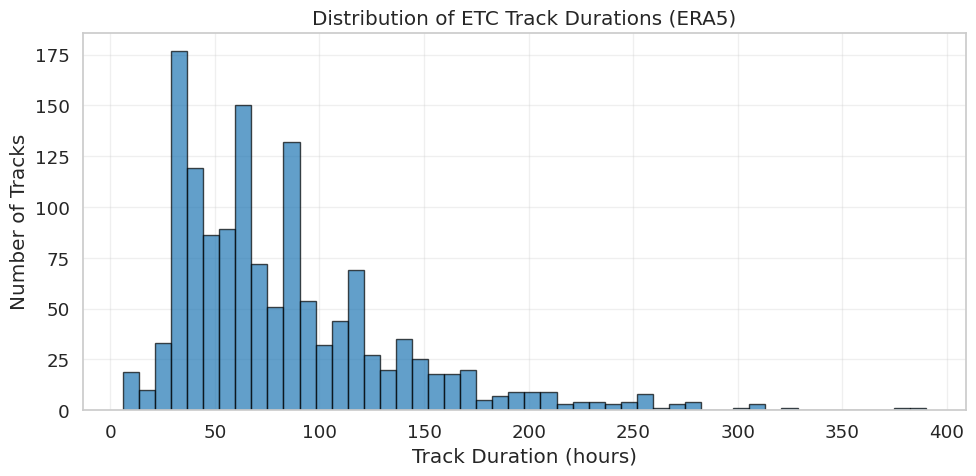

,storm_id,duration
0,1,168
1,2,66
2,3,168
3,4,54
4,5,72
5,6,84
6,7,108
7,8,12
8,9,72
9,10,126


In [7]:
# Compute track duration (number of time points per track)
time_resolution = 6     # hours per time step
track_duration = df.groupby('storm_id').size().reset_index(name='duration')
track_duration['duration'] = track_duration['duration'] * time_resolution

print(f"Track duration statistics:")
print(track_duration['duration'].describe())
print(f"\nLongest track: {track_duration['duration'].max()} hours")
print(f"Shortest track: {track_duration['duration'].min()} hours")
print(f"Median track: {track_duration['duration'].median()} hours")

# Plot distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(track_duration['duration'], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Track Duration (hours)')
ax.set_ylabel('Number of Tracks')
ax.set_title(f'Distribution of ETC Track Durations ({source.upper()})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

track_duration.head(10)

## Task 2: Compute Track Lifetime Statistics

Calculate lifetime-representative values (mean, min, max) for each track.

In [ ]:
# Example: Compute lifetime-minimum sea level pressure for each track
# Group by storm_id and compute aggregations
track_stats = df.groupby('storm_id').agg({
    'psl_min': ['min', 'mean', 'max'],  # Sea level pressure statistics
    'pr_mean': ['min', 'mean', 'max', 'sum'],  # Precipitation statistics
    'cof_lat': 'mean',  # Average latitude
    'cof_lon': 'mean',  # Average longitude
    'overlap_flag': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]  # Most common overlap type
}).reset_index()

# Flatten multi-level columns
track_stats.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                        for col in track_stats.columns.values]

# Rename for clarity
track_stats.rename(columns={
    'psl_min_min': 'psl_lifetime_min',
    'psl_min_mean': 'psl_lifetime_mean',
    'psl_min_max': 'psl_lifetime_max',
    'pr_mean_min': 'pr_lifetime_min',
    'pr_mean_mean': 'pr_lifetime_mean',
    'pr_mean_max': 'pr_lifetime_max',
    'pr_mean_sum': 'pr_lifetime_total',
    'cof_lat_mean': 'track_mean_lat',
    'cof_lon_mean': 'track_mean_lon',
    'overlap_flag_<lambda>': 'dominant_overlap_flag'
}, inplace=True)

# Convert pressure from Pa to hPa for plotting
track_stats['psl_lifetime_min_hpa'] = track_stats['psl_lifetime_min'] / 100
track_stats['psl_lifetime_mean_hpa'] = track_stats['psl_lifetime_mean'] / 100

track_stats['psl_lifetime_max_hpa'] = track_stats['psl_lifetime_max'] / 100track_stats.head()

print(f"\nColumns: {list(track_stats.columns)}")
print(f"Track statistics shape: {track_stats.shape}")

Track statistics shape: (1380, 11)

Columns: ['storm_id', 'psl_lifetime_min', 'psl_lifetime_mean', 'psl_lifetime_max', 'pr_lifetime_min', 'pr_lifetime_mean', 'pr_lifetime_max', 'pr_lifetime_total', 'track_mean_lat', 'track_mean_lon', 'dominant_overlap_flag']


,storm_id,psl_lifetime_min,psl_lifetime_mean,psl_lifetime_max,pr_lifetime_min,pr_lifetime_mean,pr_lifetime_max,pr_lifetime_total,track_mean_lat,track_mean_lon,dominant_overlap_flag
0,1,97729.437500,98333.179688,99164.234375,0.008866,0.394850,1.655703,11.055787,62.491071,55.991071,0.0
1,2,99878.328125,100278.320312,100623.156250,0.009223,0.226123,0.661609,2.487348,51.000000,144.159091,0.0
2,3,99500.234375,99865.859375,100266.820312,0.025590,0.185129,0.530062,5.183615,54.821429,305.571429,0.0
3,4,100564.875000,100727.734375,100895.867188,0.071549,0.769428,1.864792,6.924848,48.555556,234.527778,1.0
4,5,95736.718750,98862.304688,100826.531250,0.601479,1.409455,3.292425,16.913465,-47.687500,267.104167,3.0


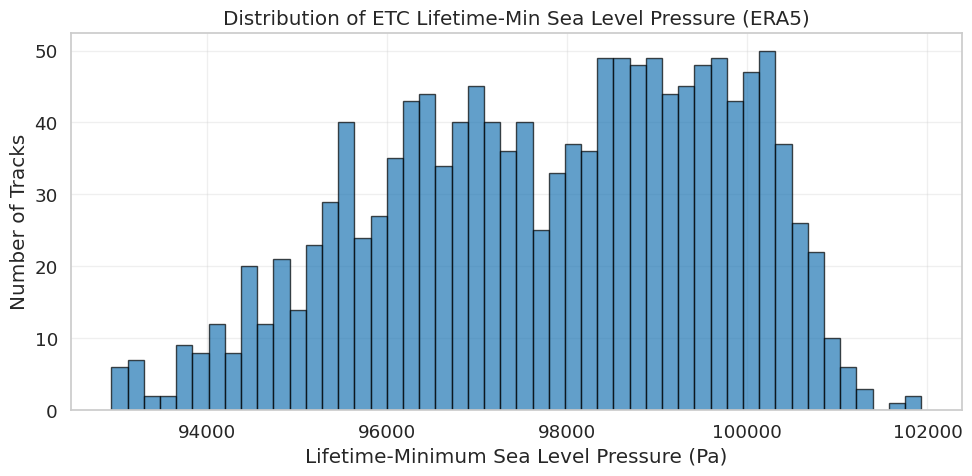


Lifetime-min sea level pressure statistics:
count      1380.000000
mean      97817.125000
std        1894.788818
min       92942.070312
25%       96380.341797
50%       98042.941406
75%       99403.675781
max      101929.539062
Name: psl_lifetime_min, dtype: float64


In [ ]:
# Visualize lifetime-min surface pressure distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(track_stats['psl_lifetime_min_hpa'], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Lifetime-Minimum Sea Level Pressure (hPa)')
ax.set_ylabel('Number of Tracks')
ax.set_title(f'Distribution of ETC Lifetime-Min Sea Level Pressure ({source.upper()})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLifetime-min sea level pressure statistics (hPa):")
print(track_stats['psl_lifetime_min_hpa'].describe())

## Overlap Flag Consistency Analysis

Analyze how consistently each track maintains a single overlap_flag type throughout its lifetime.

Distribution of dominant overlap_flag fraction (how 'pure' is each track):
count    1380.000000
mean        0.729276
std         0.203029
min         0.000000
25%         0.571429
50%         0.714286
75%         0.923077
max         1.000000
Name: fraction, dtype: float64

Tracks with 100% single overlap type: 308 (22.3%)
Tracks with >= 90% single overlap type: 376 (27.2%)
Tracks with >= 75% single overlap type: 653 (47.3%)
Tracks with >= 50% single overlap type: 1213 (87.9%)


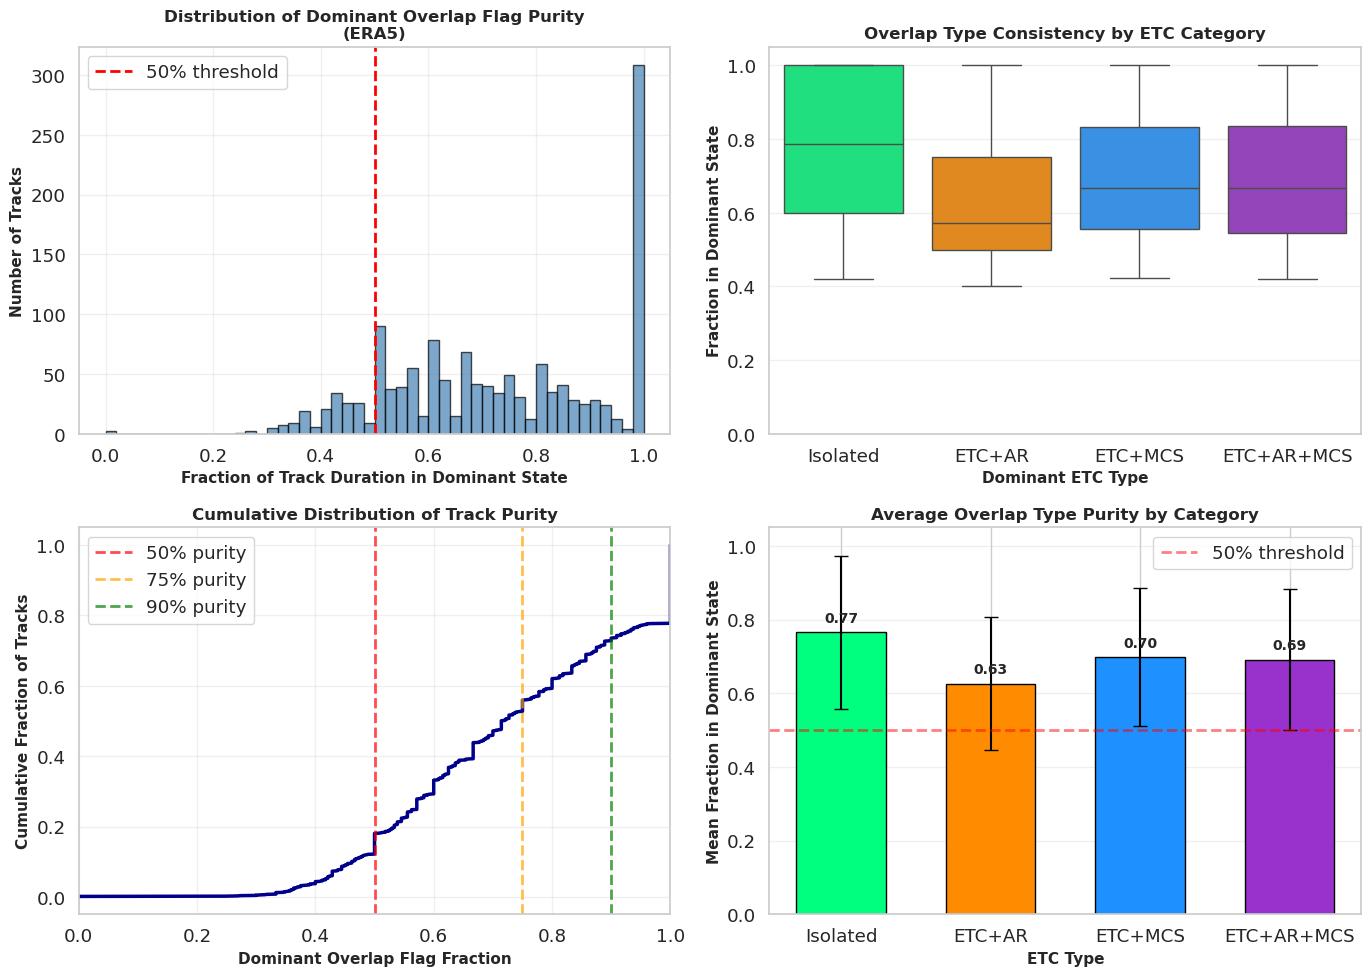


Mean dominant fraction by overlap type:
                  mean    median       std
overlap_type                              
Isolated      0.765067  0.786797  0.208023
ETC+AR        0.625461  0.571429  0.180342
ETC+MCS       0.697548  0.666667  0.187018
ETC+AR+MCS    0.690772  0.666667  0.191499



In [57]:
# Compute fraction of time each track spends in each overlap_flag state
overlap_fractions = []

for storm_id in df['storm_id'].unique():
    track_data = df[df['storm_id'] == storm_id]
    total_points = len(track_data)
    
    # Count occurrences of each overlap_flag
    flag_counts = track_data['overlap_flag'].value_counts()
    
    # Compute fractions
    for flag_value in [0, 1, 2, 3]:
        fraction = flag_counts.get(flag_value, 0) / total_points
        overlap_fractions.append({
            'storm_id': storm_id,
            'overlap_flag': flag_value,
            'fraction': fraction,
            'count': flag_counts.get(flag_value, 0),
            'total_points': total_points
        })

df_fractions = pd.DataFrame(overlap_fractions)

# Find dominant overlap_flag for each track
df_dominant = df_fractions.loc[df_fractions.groupby('storm_id')['fraction'].idxmax()]

print("Distribution of dominant overlap_flag fraction (how 'pure' is each track):")
print(df_dominant['fraction'].describe())
print(f"\nTracks with 100% single overlap type: {(df_dominant['fraction'] == 1.0).sum()} ({(df_dominant['fraction'] == 1.0).sum() / len(df_dominant) * 100:.1f}%)")
print(f"Tracks with >= 90% single overlap type: {(df_dominant['fraction'] >= 0.9).sum()} ({(df_dominant['fraction'] >= 0.9).sum() / len(df_dominant) * 100:.1f}%)")
print(f"Tracks with >= 75% single overlap type: {(df_dominant['fraction'] >= 0.75).sum()} ({(df_dominant['fraction'] >= 0.75).sum() / len(df_dominant) * 100:.1f}%)")
print(f"Tracks with >= 50% single overlap type: {(df_dominant['fraction'] >= 0.5).sum()} ({(df_dominant['fraction'] >= 0.5).sum() / len(df_dominant) * 100:.1f}%)")

# Define custom colors for ETC types
etc_colors = {
    'Isolated': 'springgreen',
    'ETC+AR': 'darkorange', 
    'ETC+MCS': 'dodgerblue',
    'ETC+AR+MCS': 'darkorchid'
}

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Histogram of dominant fraction
ax = axes[0, 0]
ax.hist(df_dominant['fraction'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='50% threshold')
ax.set_xlabel('Fraction of Track Duration in Dominant State', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Tracks', fontsize=11, fontweight='bold')
ax.set_title(f'Distribution of Dominant Overlap Flag Purity\n({source.upper()})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Boxplot by dominant overlap type
df_dominant['overlap_type'] = df_dominant['overlap_flag'].map({
    0: 'Isolated', 1: 'ETC+MCS', 2: 'ETC+AR', 3: 'ETC+AR+MCS'
})
ax = axes[0, 1]
sns.boxplot(data=df_dominant, x='overlap_type', y='fraction', 
            hue='overlap_type', legend=False, whis=[5,95], showfliers=False, 
            order=['Isolated', 'ETC+AR', 'ETC+MCS', 'ETC+AR+MCS'],
            palette=etc_colors, ax=ax)
ax.set_xlabel('Dominant ETC Type', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraction in Dominant State', fontsize=11, fontweight='bold')
ax.set_title('Overlap Type Consistency by ETC Category', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

# Panel 3: Cumulative distribution
ax = axes[1, 0]
sorted_fractions = np.sort(df_dominant['fraction'])
cumulative = np.arange(1, len(sorted_fractions) + 1) / len(sorted_fractions)
ax.plot(sorted_fractions, cumulative, linewidth=2.5, color='darkblue')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='50% purity')
ax.axvline(x=0.75, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='75% purity')
ax.axvline(x=0.9, color='green', linestyle='--', linewidth=2, alpha=0.7, label='90% purity')
ax.set_xlabel('Dominant Overlap Flag Fraction', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Fraction of Tracks', fontsize=11, fontweight='bold')
ax.set_title('Cumulative Distribution of Track Purity', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])

# Panel 4: Stacked bar chart showing overlap flag distribution
overlap_type_purity = df_dominant.groupby('overlap_type')['fraction'].agg(['mean', 'median', 'std']).reset_index()
overlap_type_purity = overlap_type_purity.set_index('overlap_type').reindex(['Isolated', 'ETC+AR', 'ETC+MCS', 'ETC+AR+MCS'])

ax = axes[1, 1]
x = np.arange(len(overlap_type_purity))
width = 0.6
# Map colors to match the order of overlap types
bar_colors = [etc_colors[ot] for ot in overlap_type_purity.index]
bars = ax.bar(x, overlap_type_purity['mean'], width, 
              yerr=overlap_type_purity['std'], capsize=5,
              color=bar_colors, alpha=1, edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='50% threshold')
ax.set_xlabel('ETC Type', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Fraction in Dominant State', fontsize=11, fontweight='bold')
ax.set_title('Average Overlap Type Purity by Category', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(overlap_type_purity.index, rotation=0, ha='center')
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional statistics
print("\n" + "="*60)
print("Mean dominant fraction by overlap type:")
print(overlap_type_purity[['mean', 'median', 'std']])
print("\n" + "="*60)

## Task 3: Box Plot by Overlap Flag (NH only)

Filter NH tracks and create box plots of lifetime-min surface pressure by ETC overlap type.

In [11]:
# Filter for Northern Hemisphere tracks (mean lat > 20°)
nh_threshold = 20.0
track_stats_nh = track_stats[track_stats['track_mean_lat'] > nh_threshold].copy()

print(f"Total tracks: {len(track_stats)}")
print(f"NH tracks (lat > {nh_threshold}°): {len(track_stats_nh)}")
print(f"\nOverlap flag distribution in NH:")
print(track_stats_nh['dominant_overlap_flag'].value_counts().sort_index())

# Create category labels for overlap flags
overlap_labels = {
    0: 'Isolated',
    1: 'ETC+MCS',
    2: 'ETC+AR',
    3: 'ETC+AR+MCS'
}
track_stats_nh['overlap_type'] = track_stats_nh['dominant_overlap_flag'].map(overlap_labels)

# Display sample
track_stats_nh[['storm_id', 'psl_lifetime_min', 'track_mean_lat', 'dominant_overlap_flag', 'overlap_type']].head()

Total tracks: 1380
NH tracks (lat > 20.0°): 656

Overlap flag distribution in NH:
dominant_overlap_flag
0.0    339
1.0    155
2.0     22
3.0    139
Name: count, dtype: int64


,storm_id,psl_lifetime_min,track_mean_lat,dominant_overlap_flag,overlap_type
0,1,97729.437500,62.491071,0.0,Isolated
1,2,99878.328125,51.000000,0.0,Isolated
2,3,99500.234375,54.821429,0.0,Isolated
3,4,100564.875000,48.555556,1.0,ETC+MCS
9,10,99562.351562,59.690476,0.0,Isolated


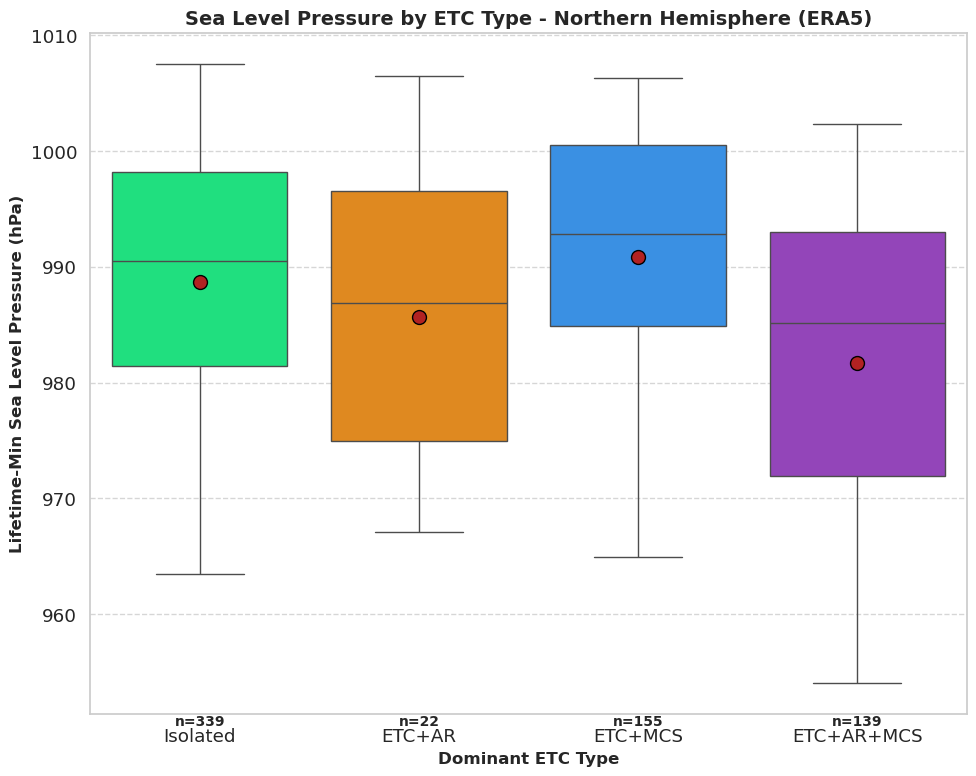


Statistical summary by overlap type (hPa):
              count        mean        std         min         25%  \
overlap_type                                                         
ETC+AR         22.0  985.663269  16.459631  954.812866  974.928284   
ETC+AR+MCS    139.0  981.647461  15.604749  931.792786  971.934113   
ETC+MCS       155.0  990.872375  12.438699  949.013733  984.875793   
Isolated      339.0  988.655029  13.580263  940.229980  981.394073   

                     50%          75%          max  
overlap_type                                        
ETC+AR        986.835663   996.533707  1011.384705  
ETC+AR+MCS    985.143616   992.978302  1005.071716  
ETC+MCS       992.791809  1000.467896  1009.335022  
Isolated      990.471802   998.163208  1019.032349  


In [31]:
# Create box plot using seaborn
# Define custom colors for each ETC type
etc_colors = {
    'Isolated': 'springgreen',
    'ETC+AR': 'darkorange', 
    'ETC+MCS': 'dodgerblue',
    'ETC+AR+MCS': 'darkorchid'
}

# Convert Pa to hPa
track_stats_nh['psl_lifetime_min_hpa'] = track_stats_nh['psl_lifetime_min'] / 100

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

meanpointprops = dict(marker='o', markeredgecolor='black',
                      markerfacecolor='firebrick', markersize=10)

sns.boxplot(data=track_stats_nh, x='overlap_type', y='psl_lifetime_min_hpa', 
            hue='overlap_type', legend=False, showfliers=False, whis=[5, 95],
            showmeans=True, meanprops=meanpointprops,
            order=['Isolated', 'ETC+AR', 'ETC+MCS', 'ETC+AR+MCS'],
            palette=etc_colors, ax=ax)

ax.set_xlabel('Dominant ETC Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Lifetime-Min Sea Level Pressure (hPa)', fontsize=12, fontweight='bold')
ax.set_title(f'Sea Level Pressure by ETC Type - Northern Hemisphere ({source.upper()})', 
             fontsize=14, fontweight='bold')
ax.grid(True, ls='--', alpha=0.8, axis='y')

# Add count labels
for i, overlap_type in enumerate(['Isolated', 'ETC+AR', 'ETC+MCS', 'ETC+AR+MCS']):
    count = len(track_stats_nh[track_stats_nh['overlap_type'] == overlap_type])
    ax.text(i, ax.get_ylim()[0], f'n={count}', 
            ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistical summary by overlap type
print("\nStatistical summary by overlap type (hPa):")
print(track_stats_nh.groupby('overlap_type')['psl_lifetime_min_hpa'].describe())

## Task 4: Composite Track Evolution (Relative Lifetime)

Normalize each track to relative lifetime (0 to 1) and compute composites.

In [34]:
def interpolate_track_to_relative_time(df, storm_id, variable='psl_min', n_steps=20):
    """
    Interpolate a single track to normalized relative time.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Full dataframe
    storm_id : int
        Storm ID to interpolate
    variable : str
        Variable name to interpolate
    n_steps : int
        Number of interpolation steps (default: 20)
    
    Returns:
    --------
    pandas.Series : Interpolated values at relative time steps
    """
    # Extract track data
    track_data = df[df['storm_id'] == storm_id].copy()
    
    # Sort by time (important!)
    if 'time' in track_data.columns:
        track_data = track_data.sort_values('time')
    
    if len(track_data) < 2:
        return pd.Series([np.nan] * n_steps)
    
    # Check if variable exists and has valid data
    if variable not in track_data.columns:
        print(f"WARNING: Variable '{variable}' not found in dataframe")
        return pd.Series([np.nan] * n_steps)
    
    # Drop NaN values in the variable
    track_data = track_data.dropna(subset=[variable])
    
    if len(track_data) < 2:
        return pd.Series([np.nan] * n_steps)
    
    # Create relative time (0 to 1)
    track_data['relative_time'] = np.linspace(0, 1, len(track_data))
    
    # Interpolate to uniform grid
    relative_grid = np.linspace(0, 1, n_steps)
    
    try:
        interpolated = np.interp(relative_grid, track_data['relative_time'], track_data[variable])
    except Exception as e:
        print(f"WARNING: Interpolation failed for storm_id {storm_id}: {e}")
        return pd.Series([np.nan] * n_steps)
    
    return pd.Series(interpolated, index=relative_grid)


def compute_composite_evolution(df, storm_ids, variable='psl_min', n_steps=20):
    """
    Compute composite evolution across multiple tracks.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Full dataframe
    storm_ids : array-like
        List of storm IDs to include
    variable : str
        Variable to composite
    n_steps : int
        Number of time steps in normalized timeline
    
    Returns:
    --------
    pandas.DataFrame : Composite statistics (median, Q25, Q75)
    """
    print(f"Processing {len(storm_ids)} tracks for variable '{variable}'...")
    
    # Interpolate all tracks
    interpolated_tracks = []
    failed_count = 0
    
    for sid in storm_ids:
        interp_values = interpolate_track_to_relative_time(df, sid, variable, n_steps)
        
        # Check if interpolation succeeded (not all NaN)
        if not interp_values.isna().all():
            interpolated_tracks.append(interp_values)
        else:
            failed_count += 1
    
    if failed_count > 0:
        print(f"  WARNING: {failed_count} tracks failed interpolation")
    
    if len(interpolated_tracks) == 0:
        print(f"  ERROR: No valid tracks to composite!")
        return pd.DataFrame()
    
    print(f"  Successfully interpolated {len(interpolated_tracks)} tracks")
    
    # Convert to DataFrame
    interp_df = pd.DataFrame(interpolated_tracks)
    
    # Compute statistics across tracks
    composite = pd.DataFrame({
        'relative_time': np.linspace(0, 1, n_steps),
        'median': interp_df.median(axis=0),
        'q25': interp_df.quantile(0.25, axis=0),
        'q75': interp_df.quantile(0.75, axis=0),
        'mean': interp_df.mean(axis=0),
        'std': interp_df.std(axis=0),
        'count': interp_df.count(axis=0)
    })
    
    return composite


# Test with a single track
sample_storm_id = df['storm_id'].iloc[0]
sample_track = interpolate_track_to_relative_time(df, sample_storm_id, variable='psl_min', n_steps=20)

print(f"Sample track interpolation (storm_id={sample_storm_id}):")
print(sample_track)
print(f"\nShape: {sample_track.shape}")

Sample track interpolation (storm_id=1):
0.000000    98393.687500
0.052632    98242.180921
0.105263    98132.435855
0.157895    97824.255757
0.210526    97982.697780
0.263158    98160.278783
0.315789    98109.780839
0.368421    98283.171464
0.421053    97968.977796
0.473684    97736.302632
0.526316    98009.047286
0.578947    98603.326069
0.631579    99121.953536
0.684211    98358.829770
0.736842    98488.120477
0.789474    98593.754523
0.842105    98426.403783
0.894737    98632.222862
0.947368    98899.710526
1.000000    99053.796875
dtype: float64

Shape: (20,)


In [46]:
# Filter for NH tracks
df_nh = df[df['cof_lat'] > nh_threshold].copy()

# Convert pressure from Pa to hPa for composite analysis
df_nh['psl_min_hpa'] = df_nh['psl_min'] / 100

n_steps = 15

nh_storm_ids = df_nh['storm_id'].unique()
composite_psl = compute_composite_evolution(df_nh, nh_storm_ids, variable='psl_min_hpa', n_steps=n_steps)
print(f"Number of NH tracks: {len(nh_storm_ids)}")

# Compute composite evolution for NH ETCs
# composite_psl = compute_composite_evolution(df_nh, nh_storm_ids, variable='psl_min', n_steps=n_steps)
composite_pr = compute_composite_evolution(df_nh, nh_storm_ids, variable='pr_mean', n_steps=n_steps)

print("\nComposite min sea level pressure evolution:")
print(composite_pr.head())

print(composite_psl.head())
print("\nComposite precipitation evolution:")

Processing 656 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 650 tracks
Number of NH tracks: 656
Processing 656 tracks for variable 'pr_mean'...
  Successfully interpolated 650 tracks
Number of NH tracks: 656
Processing 656 tracks for variable 'pr_mean'...
  Successfully interpolated 650 tracks

Composite min sea level pressure evolution:
          relative_time    median       q25       q75      mean       std  \
0.000000       0.000000  0.218066  0.023976  0.771443  0.536769  0.737573   
0.071429       0.071429  0.232676  0.036474  0.729705  0.508350  0.684396   
0.142857       0.142857  0.222877  0.035761  0.643780  0.457889  0.626561   
0.214286       0.214286  0.210768  0.042899  0.559351  0.416433  0.568545   
0.285714       0.285714  0.199553  0.046846  0.533772  0.414554  0.579574   

          count  
0.000000    650  
0.071429    650  
0.142857    650  
0.214286    650  
0.285714    650  
          relative_time       median         q25          q75        

In [47]:
# # Diagnostic: Check data availability
# print("Available columns in df_nh:")
# print(list(df_nh.columns))
# print(f"\nDataFrame shape: {df_nh.shape}")
# print(f"\nSample of psl_min values:")
# print(df_nh['psl_min'].describe())
# print(f"\nNumber of NaN in psl_min: {df_nh['psl_min'].isna().sum()}")
# print(f"Number of NaN in pr_mean: {df_nh['pr_mean'].isna().sum()}")

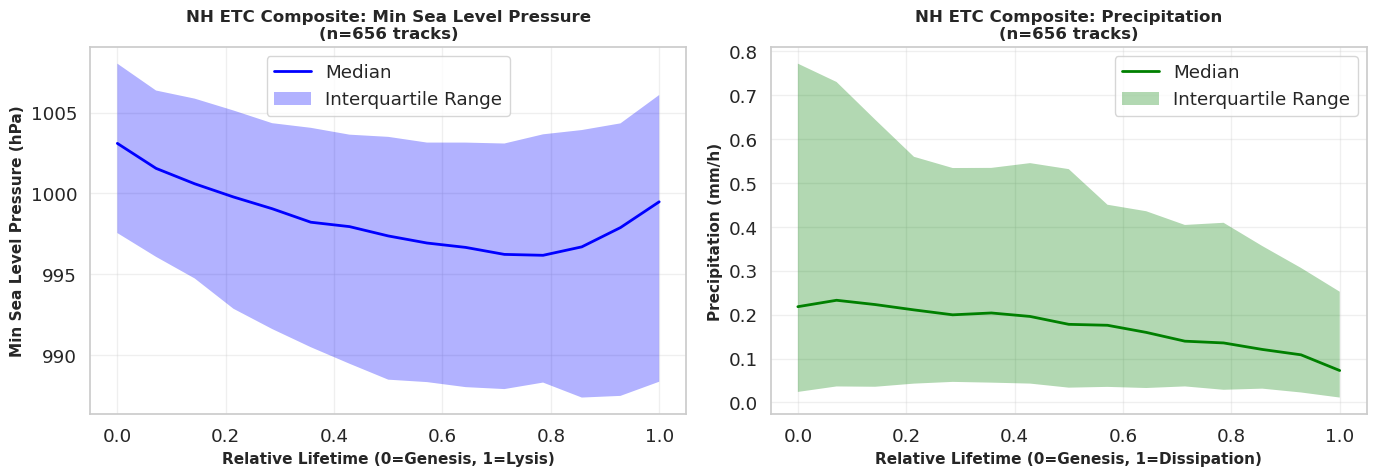

In [48]:
# Plot composite evolution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Surface Pressure
ax = axes[0]
ax.plot(composite_psl['relative_time'], composite_psl['median'], 'b-', linewidth=2, label='Median')
ax.fill_between(composite_psl['relative_time'], composite_psl['q25'], composite_psl['q75'], 
                alpha=0.3, color='blue', edgecolor='none', label='Interquartile Range')
ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Lysis)', fontsize=11, fontweight='bold')
ax.set_ylabel('Min Sea Level Pressure (hPa)', fontsize=11, fontweight='bold')
ax.set_title(f'NH ETC Composite: Min Sea Level Pressure\n(n={len(nh_storm_ids)} tracks)', 
            fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Panel 2: Precipitation
ax = axes[1]
ax.plot(composite_pr['relative_time'], composite_pr['median'], 'g-', linewidth=2, label='Median')
ax.fill_between(composite_pr['relative_time'], composite_pr['q25'], composite_pr['q75'], 
                alpha=0.3, color='green', edgecolor='none', label='Interquartile Range')
ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Dissipation)', fontsize=11, fontweight='bold')
ax.set_ylabel('Precipitation (mm/h)', fontsize=11, fontweight='bold')
ax.set_title(f'NH ETC Composite: Precipitation\n(n={len(nh_storm_ids)} tracks)', 
            fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bonus: Composite Evolution by Overlap Type

Compare lifecycle evolution across different ETC overlap types.

In [49]:
# Assign dominant overlap flag to each track
track_overlap = df_nh.groupby('storm_id')['overlap_flag'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
).reset_index()
track_overlap.columns = ['storm_id', 'dominant_overlap_flag']
track_overlap['overlap_type'] = track_overlap['dominant_overlap_flag'].map(overlap_labels)

print("NH tracks by overlap type:")
print(track_overlap['overlap_type'].value_counts())

# Compute composites for each overlap type
composites_by_type = {}
n_steps = 15

for overlap_flag, overlap_name in overlap_labels.items():
    storm_ids = track_overlap[track_overlap['dominant_overlap_flag'] == overlap_flag]['storm_id'].values
    
    if len(storm_ids) > 5:  # Only compute if enough tracks
        comp = compute_composite_evolution(df_nh, storm_ids, variable='psl_min_hpa', n_steps=n_steps)
        comp['overlap_type'] = overlap_name
        comp['n_tracks'] = len(storm_ids)
        composites_by_type[overlap_name] = comp
        print(f"  {overlap_name}: {len(storm_ids)} tracks")

# Combine all composites
all_composites = pd.concat(composites_by_type.values(), ignore_index=True)
all_composites.head()

NH tracks by overlap type:
overlap_type
Isolated      339
ETC+MCS       155
ETC+AR+MCS    139
ETC+AR         22
Name: count, dtype: int64
Processing 339 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 335 tracks
  Isolated: 339 tracks
Processing 155 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 335 tracks
  Isolated: 339 tracks
Processing 155 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 155 tracks
  ETC+MCS: 155 tracks
Processing 22 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 21 tracks
  ETC+AR: 22 tracks
Processing 139 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 155 tracks
  ETC+MCS: 155 tracks
Processing 22 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 21 tracks
  ETC+AR: 22 tracks
Processing 139 tracks for variable 'psl_min_hpa'...
  Successfully interpolated 139 tracks
  ETC+AR+MCS: 139 tracks
  Successfully interpolated 139 tracks
  ETC+AR+MCS: 139 tracks


,relative_time,median,q25,q75,mean,std,count,overlap_type,n_tracks
0,0.000000,1002.230103,995.133575,1007.603943,1000.636069,10.779668,335,Isolated,339
1,0.071429,1000.477744,994.561787,1005.798233,999.079125,10.811303,335,Isolated,339
2,0.142857,999.743958,991.778952,1005.098655,997.949834,11.115133,335,Isolated,339
3,0.214286,999.143127,990.545216,1004.633933,997.284708,11.470982,335,Isolated,339
4,0.285714,998.159694,989.709137,1003.998779,996.600518,11.684619,335,Isolated,339


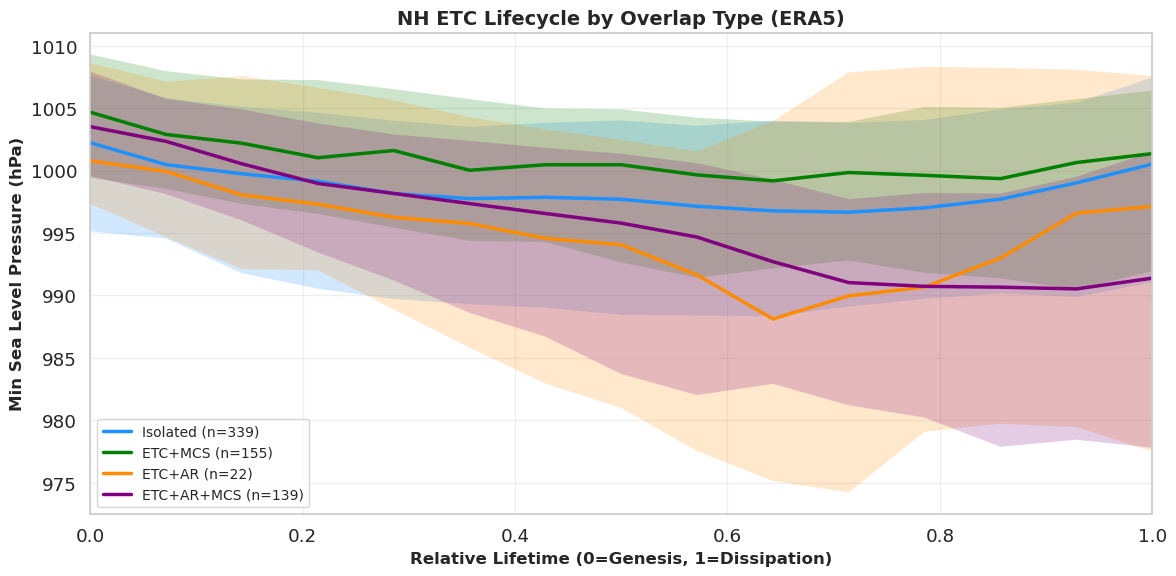

In [51]:
# Plot composites by overlap type
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors = {'Isolated': 'dodgerblue', 'ETC+AR': 'darkorange', 'ETC+MCS': 'green', 'ETC+AR+MCS': 'purple'}

for overlap_name, comp_data in composites_by_type.items():
    ax.plot(comp_data['relative_time'], comp_data['median'], 
           color=colors[overlap_name], linewidth=2.5, 
           label=f"{overlap_name} (n={comp_data['n_tracks'].iloc[0]})")
    ax.fill_between(comp_data['relative_time'], comp_data['q25'], comp_data['q75'], 
                   alpha=0.2, color=colors[overlap_name], edgecolor='none')

ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Dissipation)', fontsize=12, fontweight='bold')
ax.set_ylabel('Min Sea Level Pressure (hPa)', fontsize=12, fontweight='bold')
ax.set_title(f'NH ETC Lifecycle by Overlap Type ({source.upper()})',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Overlap Frequency During ETC Lifecycle

Analyze when overlaps (ETC+AR, ETC+MCS, ETC+AR+MCS) occur during the ETC lifecycle.

In [58]:
# For each overlap type, compute frequency of overlap occurring at each relative time
# Frequency = fraction of tracks that have that overlap_flag at each time step

# Define the three overlap types we want to analyze
overlap_types_to_analyze = {
    1: 'ETC+MCS',
    2: 'ETC+AR', 
    3: 'ETC+AR+MCS'
}

n_steps = 15
overlap_frequency_composites = {}

for overlap_flag_value, overlap_name in overlap_types_to_analyze.items():
    print(f"\nProcessing overlap frequency for {overlap_name}...")
    
    # Get all NH storm IDs
    all_storm_ids = df_nh['storm_id'].unique()
    
    # For each storm, create a binary indicator of whether it has this overlap at each time
    binary_tracks = []
    
    for sid in all_storm_ids:
        track_data = df_nh[df_nh['storm_id'] == sid].copy().sort_values('time')
        
        if len(track_data) < 2:
            continue
        
        # Create binary indicator: 1 if overlap_flag equals our target, 0 otherwise
        binary_indicator = (track_data['overlap_flag'] == overlap_flag_value).astype(float)
        
        # Interpolate to relative time
        relative_time = np.linspace(0, 1, len(track_data))
        relative_grid = np.linspace(0, 1, n_steps)
        
        try:
            # Use nearest neighbor for binary data to preserve 0/1 values
            interpolated = np.interp(relative_grid, relative_time, binary_indicator.values)
            binary_tracks.append(interpolated)
        except:
            continue
    
    # Convert to DataFrame and compute mean (= frequency)
    binary_df = pd.DataFrame(binary_tracks)
    
    frequency_composite = pd.DataFrame({
        'relative_time': np.linspace(0, 1, n_steps),
        'median': binary_df.median(axis=0),
        'q25': binary_df.quantile(0.25, axis=0),
        'q75': binary_df.quantile(0.75, axis=0),
        'mean': binary_df.mean(axis=0),  # This is the frequency
        'std': binary_df.std(axis=0),
        'count': binary_df.count(axis=0)
    })
    
    overlap_frequency_composites[overlap_name] = frequency_composite
    print(f"  Successfully processed {len(binary_tracks)} tracks")

print("\nOverlap frequency composites computed!")


Processing overlap frequency for ETC+MCS...
  Successfully processed 650 tracks

Processing overlap frequency for ETC+AR...
  Successfully processed 650 tracks

Processing overlap frequency for ETC+AR...
  Successfully processed 650 tracks

Processing overlap frequency for ETC+AR+MCS...
  Successfully processed 650 tracks

Processing overlap frequency for ETC+AR+MCS...
  Successfully processed 650 tracks

Overlap frequency composites computed!
  Successfully processed 650 tracks

Overlap frequency composites computed!


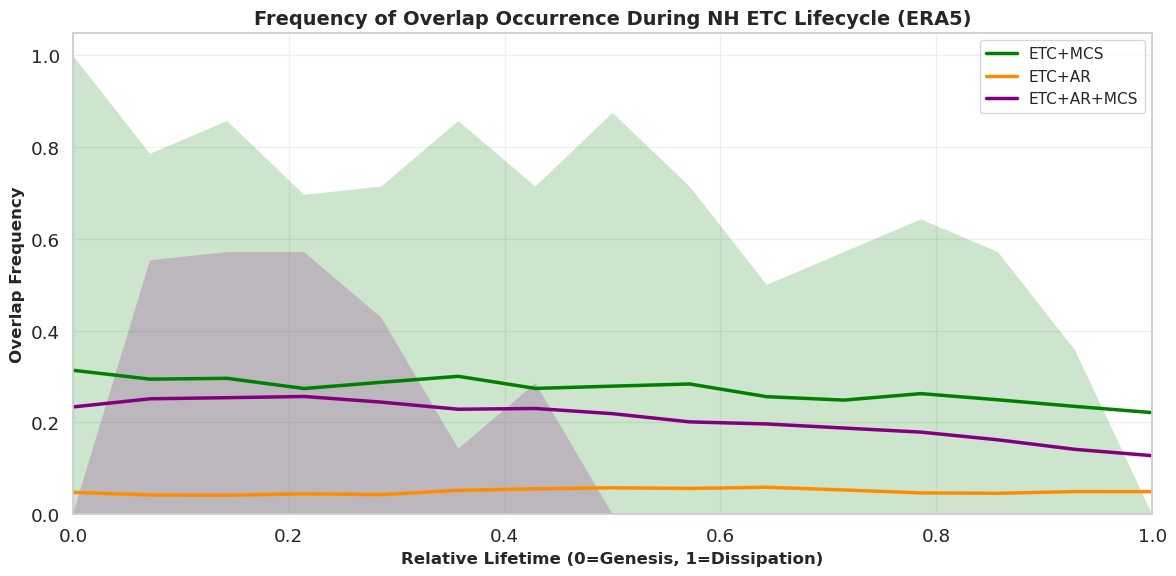


Summary: Mean overlap frequency across lifecycle
ETC+MCS: 0.272 (±0.026)
ETC+AR: 0.050 (±0.006)
ETC+AR+MCS: 0.208 (±0.041)


In [61]:
# Plot overlap frequency during ETC lifecycle
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors_overlap = {'ETC+AR': 'darkorange', 'ETC+MCS': 'green', 'ETC+AR+MCS': 'purple'}

for overlap_name, freq_data in overlap_frequency_composites.items():
    ax.plot(freq_data['relative_time'], freq_data['mean'], 
           color=colors_overlap[overlap_name], linewidth=2.5, 
           label=f"{overlap_name}")
    ax.fill_between(freq_data['relative_time'], freq_data['q25'], freq_data['q75'], 
                   alpha=0.2, color=colors_overlap[overlap_name], edgecolor='none')

ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Dissipation)', fontsize=12, fontweight='bold')
ax.set_ylabel('Overlap Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Frequency of Overlap Occurrence During NH ETC Lifecycle ({source.upper()})',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary: Mean overlap frequency across lifecycle")
for overlap_name, freq_data in overlap_frequency_composites.items():
    print(f"{overlap_name}: {freq_data['mean'].mean():.3f} (±{freq_data['mean'].std():.3f})")

## Fractional Area Evolution of AR and MCS Features

Analyze the fractional area coverage of AR and MCS features during the ETC lifecycle.

In [64]:
df_nh.keys()

Index(['time', 'd2m_mean', 'd2m_min', 'd2m_max', 'hur_500hPa_mean',
       'hur_500hPa_min', 'hur_500hPa_max', 'hur_850hPa_mean', 'hur_850hPa_min',
       'hur_850hPa_max', 'hus_500hPa_mean', 'hus_500hPa_min', 'hus_500hPa_max',
       'hus_850hPa_mean', 'hus_850hPa_min', 'hus_850hPa_max',
       'omega_500hPa_mean', 'omega_500hPa_min', 'omega_500hPa_max',
       'omega_850hPa_mean', 'omega_850hPa_min', 'omega_850hPa_max', 'pr_mean',
       'pr_min', 'pr_max', 'prw_mean', 'prw_min', 'prw_max', 'ps_mean',
       'ps_min', 'ps_max', 'psl_mean', 'psl_min', 'psl_max', 'sstk_mean',
       'sstk_min', 'sstk_max', 'tas_mean', 'tas_min', 'tas_max', 'u10_mean',
       'u10_min', 'u10_max', 'ua_500hPa_mean', 'ua_500hPa_min',
       'ua_500hPa_max', 'ua_850hPa_mean', 'ua_850hPa_min', 'ua_850hPa_max',
       'v10_mean', 'v10_min', 'v10_max', 'va_500hPa_mean', 'va_500hPa_min',
       'va_500hPa_max', 'va_850hPa_mean', 'va_850hPa_min', 'va_850hPa_max',
       'zg_500hPa_mean', 'zg_500hPa_min', 'zg_50

In [65]:
# Compute fractional area composites for different overlap types
# For ETC+AR: use ar_etc_overlap_mask_frac_r10 (AR fraction in ETC+AR overlap)
# For ETC+MCS: use mcs_etc_overlap_mask_frac_r10 (MCS fraction in ETC+MCS overlap)
# For ETC+AR+MCS: use ar_mcs_etc_overlap_mask_frac_r10 (AR fraction) and mcs_ar_etc_overlap_mask_frac_r10 (MCS fraction) separately

n_steps = 15
frac_area_composites = {}

# ETC+AR type: fractional area of AR
print("\nProcessing fractional area for ETC+AR...")
etcar_storm_ids = track_overlap[track_overlap['dominant_overlap_flag'] == 2]['storm_id'].values
if len(etcar_storm_ids) > 5:
    comp_ar = compute_composite_evolution(df_nh, etcar_storm_ids, variable='ar_etc_overlap_mask_frac_r10', n_steps=n_steps)
    comp_ar['overlap_type'] = 'ETC+AR (AR area)'
    comp_ar['n_tracks'] = len(etcar_storm_ids)
    frac_area_composites['ETC+AR_ar'] = comp_ar

# ETC+MCS type: fractional area of MCS
print("\nProcessing fractional area for ETC+MCS...")
etcmcs_storm_ids = track_overlap[track_overlap['dominant_overlap_flag'] == 1]['storm_id'].values
if len(etcmcs_storm_ids) > 5:
    comp_mcs = compute_composite_evolution(df_nh, etcmcs_storm_ids, variable='mcs_etc_overlap_mask_frac_r10', n_steps=n_steps)
    comp_mcs['overlap_type'] = 'ETC+MCS (MCS area)'
    comp_mcs['n_tracks'] = len(etcmcs_storm_ids)
    frac_area_composites['ETC+MCS_mcs'] = comp_mcs

# ETC+AR+MCS type: fractional area of both AR and MCS separately
print("\nProcessing fractional area for ETC+AR+MCS...")
etcarmcs_storm_ids = track_overlap[track_overlap['dominant_overlap_flag'] == 3]['storm_id'].values
if len(etcarmcs_storm_ids) > 5:
    # AR fractional area in triple overlap
    comp_armcs_ar = compute_composite_evolution(df_nh, etcarmcs_storm_ids, variable='ar_mcs_etc_overlap_mask_frac_r10', n_steps=n_steps)
    comp_armcs_ar['overlap_type'] = 'ETC+AR+MCS (AR area)'
    comp_armcs_ar['n_tracks'] = len(etcarmcs_storm_ids)
    frac_area_composites['ETC+AR+MCS_ar'] = comp_armcs_ar
    
    # MCS fractional area in triple overlap
    comp_armcs_mcs = compute_composite_evolution(df_nh, etcarmcs_storm_ids, variable='mcs_ar_etc_overlap_mask_frac_r10', n_steps=n_steps)
    comp_armcs_mcs['overlap_type'] = 'ETC+AR+MCS (MCS area)'
    comp_armcs_mcs['n_tracks'] = len(etcarmcs_storm_ids)
    frac_area_composites['ETC+AR+MCS_mcs'] = comp_armcs_mcs

print("\nFractional area composites computed!")


Processing fractional area for ETC+AR...
Processing 22 tracks for variable 'ar_etc_overlap_mask_frac_r10'...
  Successfully interpolated 21 tracks

Processing fractional area for ETC+MCS...
Processing 155 tracks for variable 'mcs_etc_overlap_mask_frac_r10'...
  Successfully interpolated 155 tracks

Processing fractional area for ETC+AR+MCS...
Processing 139 tracks for variable 'ar_mcs_etc_overlap_mask_frac_r10'...
  Successfully interpolated 139 tracks
  Successfully interpolated 155 tracks

Processing fractional area for ETC+AR+MCS...
Processing 139 tracks for variable 'ar_mcs_etc_overlap_mask_frac_r10'...
  Successfully interpolated 139 tracks
Processing 139 tracks for variable 'mcs_ar_etc_overlap_mask_frac_r10'...
  Successfully interpolated 139 tracks

Fractional area composites computed!
Processing 139 tracks for variable 'mcs_ar_etc_overlap_mask_frac_r10'...
  Successfully interpolated 139 tracks

Fractional area composites computed!


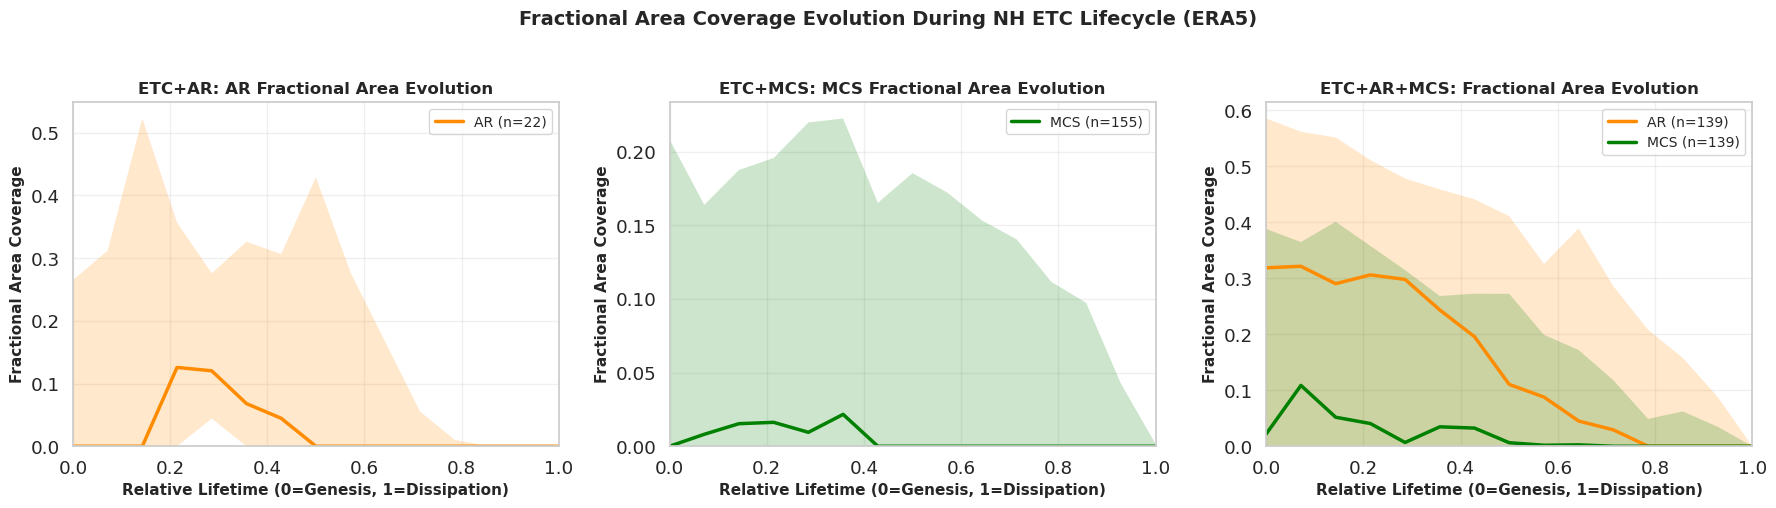

In [66]:
# Plot fractional area evolution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: ETC+AR
ax = axes[0]
if 'ETC+AR_ar' in frac_area_composites:
    comp_data = frac_area_composites['ETC+AR_ar']
    ax.plot(comp_data['relative_time'], comp_data['median'], 
           color='darkorange', linewidth=2.5, 
           label=f"AR (n={comp_data['n_tracks'].iloc[0]})")
    ax.fill_between(comp_data['relative_time'], comp_data['q25'], comp_data['q75'], 
                   alpha=0.2, color='darkorange', edgecolor='none')
ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Dissipation)', fontsize=11, fontweight='bold')
ax.set_ylabel('Fractional Area Coverage', fontsize=11, fontweight='bold')
ax.set_title('ETC+AR: AR Fractional Area Evolution', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

# Panel 2: ETC+MCS
ax = axes[1]
if 'ETC+MCS_mcs' in frac_area_composites:
    comp_data = frac_area_composites['ETC+MCS_mcs']
    ax.plot(comp_data['relative_time'], comp_data['median'], 
           color='green', linewidth=2.5, 
           label=f"MCS (n={comp_data['n_tracks'].iloc[0]})")
    ax.fill_between(comp_data['relative_time'], comp_data['q25'], comp_data['q75'], 
                   alpha=0.2, color='green', edgecolor='none')
ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Dissipation)', fontsize=11, fontweight='bold')
ax.set_ylabel('Fractional Area Coverage', fontsize=11, fontweight='bold')
ax.set_title('ETC+MCS: MCS Fractional Area Evolution', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

# Panel 3: ETC+AR+MCS (both AR and MCS on same plot)
ax = axes[2]
if 'ETC+AR+MCS_ar' in frac_area_composites:
    comp_ar = frac_area_composites['ETC+AR+MCS_ar']
    ax.plot(comp_ar['relative_time'], comp_ar['median'], 
           color='darkorange', linewidth=2.5, linestyle='-',
           label=f"AR (n={comp_ar['n_tracks'].iloc[0]})")
    ax.fill_between(comp_ar['relative_time'], comp_ar['q25'], comp_ar['q75'], 
                   alpha=0.2, color='darkorange', edgecolor='none')
    
if 'ETC+AR+MCS_mcs' in frac_area_composites:
    comp_mcs = frac_area_composites['ETC+AR+MCS_mcs']
    # Plot MCS fractional area separately from AR
    ax.plot(comp_mcs['relative_time'], comp_mcs['median'], 
           color='green', linewidth=2.5, linestyle='-',
           label=f"MCS (n={comp_mcs['n_tracks'].iloc[0]})")
    ax.fill_between(comp_mcs['relative_time'], comp_mcs['q25'], comp_mcs['q75'], 
                   alpha=0.2, color='green', edgecolor='none')
    
ax.set_xlabel('Relative Lifetime (0=Genesis, 1=Dissipation)', fontsize=11, fontweight='bold')
ax.set_ylabel('Fractional Area Coverage', fontsize=11, fontweight='bold')
ax.set_title('ETC+AR+MCS: Fractional Area Evolution', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

plt.suptitle(f'Fractional Area Coverage Evolution During NH ETC Lifecycle ({source.upper()})', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Alternative: Convert to Track-Based Xarray Format

If you prefer the traditional `[tracks, times]` format, here's how to convert.

In [52]:
def convert_to_track_time_format(df, variables=None):
    """
    Convert DataFrame to xarray Dataset with [tracks, times] dimensions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with storm_id and time columns
    variables : list, optional
        List of variables to include. If None, includes all numeric columns.
    
    Returns:
    --------
    xr.Dataset : Dataset with dimensions [tracks, times]
    """
    # Get unique tracks and find max length
    unique_tracks = df['storm_id'].unique()
    max_length = df.groupby('storm_id').size().max()
    
    print(f"Number of tracks: {len(unique_tracks)}")
    print(f"Max track length: {max_length} time steps")
    
    # Select variables to include
    if variables is None:
        # Exclude time, storm_id, and non-numeric columns
        variables = df.select_dtypes(include=[np.number]).columns.tolist()
        variables = [v for v in variables if v not in ['storm_id', 'time']]
    
    print(f"Variables to convert: {len(variables)}")
    
    # Create empty arrays for each variable
    data_vars = {}
    
    for var in variables:
        # Initialize array with NaN
        data_array = np.full((len(unique_tracks), max_length), np.nan)
        
        # Fill in data for each track
        for i, storm_id in enumerate(unique_tracks):
            track_data = df[df['storm_id'] == storm_id].sort_values('time')
            track_values = track_data[var].values
            data_array[i, :len(track_values)] = track_values
        
        data_vars[var] = (['tracks', 'times'], data_array)
    
    # Create coordinate for storm_id
    coords = {
        'tracks': unique_tracks,
        'times': np.arange(max_length),
        'storm_id': ('tracks', unique_tracks)
    }
    
    # Create xarray Dataset
    ds_tracks = xr.Dataset(data_vars, coords=coords)
    
    # Add attributes
    ds_tracks.attrs['description'] = 'ETC track statistics in [tracks, times] format'
    ds_tracks.attrs['max_track_length'] = max_length
    ds_tracks.attrs['n_tracks'] = len(unique_tracks)
    
    return ds_tracks


# Convert a subset of variables to track format
variables_to_convert = ['psl_min', 'pr_mean', 'cof_lat', 'cof_lon', 'overlap_flag']
ds_tracks = convert_to_track_time_format(df_nh, variables=variables_to_convert)

print("\n" + "="*60)
print("Converted Dataset:")
print("="*60)
ds_tracks

Number of tracks: 656
Max track length: 65 time steps
Variables to convert: 5

Converted Dataset:

Converted Dataset:


<xarray.Dataset> Size: 2MB
Dimensions:       (tracks: 656, times: 65)
Coordinates:
  * tracks        (tracks) int64 5kB 1 2 3 4 10 11 ... 1393 1394 1385 1399 1401
  * times         (times) int64 520B 0 1 2 3 4 5 6 7 ... 57 58 59 60 61 62 63 64
    storm_id      (tracks) int64 5kB 1 2 3 4 10 11 ... 1393 1394 1385 1399 1401
Data variables:
    psl_min       (tracks, times) float64 341kB 9.839e+04 9.823e+04 ... nan nan
    pr_mean       (tracks, times) float64 341kB 0.3147 0.08039 ... nan nan
    cof_lat       (tracks, times) float64 341kB 54.5 56.0 57.0 ... nan nan nan
    cof_lon       (tracks, times) float64 341kB 56.25 56.0 60.0 ... nan nan nan
    overlap_flag  (tracks, times) float64 341kB 2.0 3.0 3.0 3.0 ... nan nan nan
Attributes:
    description:       ETC track statistics in [tracks, times] format
    max_track_length:  65
    n_tracks:          656

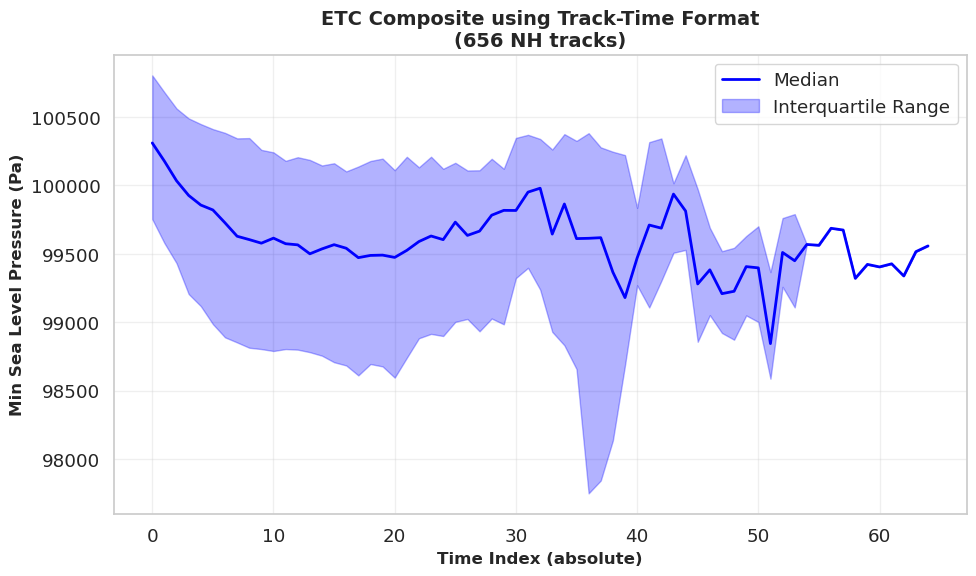


Note: This uses absolute time indices, not relative lifetime.
For relative lifetime composites, use the Pandas approach shown earlier.


In [53]:
# Example: Compute composite using xarray operations
# Composite surface pressure across all tracks (ignoring NaNs)
composite_ps_xr = ds_tracks['psl_min'].median(dim='tracks', skipna=True)
composite_ps_q25 = ds_tracks['psl_min'].quantile(0.25, dim='tracks', skipna=True)
composite_ps_q75 = ds_tracks['psl_min'].quantile(0.75, dim='tracks', skipna=True)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(composite_ps_xr.times, composite_ps_xr, 'b-', linewidth=2, label='Median')
ax.fill_between(composite_ps_xr.times, composite_ps_q25, composite_ps_q75, 
                alpha=0.3, color='blue', label='Interquartile Range')
ax.set_xlabel('Time Index (absolute)', fontsize=12, fontweight='bold')
ax.set_ylabel('Min Sea Level Pressure (Pa)', fontsize=12, fontweight='bold')
ax.set_title(f'ETC Composite using Track-Time Format\n({len(ds_tracks.tracks)} NH tracks)', 
            fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: This uses absolute time indices, not relative lifetime.")
print("For relative lifetime composites, use the Pandas approach shown earlier.")

## Summary

This notebook demonstrates several approaches for track-based analysis:

### Pandas Approach (Recommended for most tasks):
✅ **Flexible filtering** - Easy to filter by lat, overlap_flag, etc.  
✅ **Track statistics** - Simple groupby operations for lifetime min/max/mean  
✅ **Relative time composites** - Normalize each track to 0-1 timeline  
✅ **Seaborn integration** - Beautiful statistical plots with minimal code

### Xarray [tracks, times] Format:
✅ **Familiar structure** - Traditional track statistics format  
✅ **Xarray operations** - Use .median(), .quantile() across tracks  
⚠️ **Memory intensive** - Square arrays with many NaNs  
⚠️ **Less flexible** - Harder to filter and normalize to relative time

### Key Takeaways:
- **Duration**: Use `df.groupby('storm_id').size()`
- **Lifetime stats**: Use `df.groupby('storm_id').agg({'var': ['min', 'mean', 'max']})`
- **Filtering**: Standard pandas boolean indexing
- **Relative time composites**: Interpolate each track to 0-1, then compute quantiles
- **Box plots**: Seaborn's `sns.boxplot()` is perfect for categorical comparisons